We will now look at adding the sun forcer to the coupled system. K is still the same for all

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
import math

In [3]:
#defined parameters that don't need function
#make functions for other parameters
#randomly generat the data at t=0
#get data over time
#plot 

In [71]:
K=10 #Coupling strength
N=10 #Number of oscillator
A=10 #Forcing strength
number_time_steps=20 #Number of time steps
time_step=0.01 
Omega=2*np.pi/24 #Natural frequency of sun in hours
omega_array=make_omega_array(N)#makes array of oscillators natural frequencies
theta_array=make_theta_array(N)#makes array of oscillator phases

In [72]:
def make_omega_array(N):
    omega_array = np.random.normal(0, 1, N)
    return omega_array

In [73]:
def make_theta_array(N):
    theta_array = np.random.uniform(-np.pi, np.pi, N)
    return theta_array

In [74]:
print(omega_array, theta_array)

[-0.12417428  0.78998173  1.15275573  0.2740313  -0.10098844  0.719142
 -1.49517977  0.10814411 -0.94112996 -0.37670955] [-0.7477106  -0.93231707 -1.32729589  2.02920318  1.64429132 -1.39285305
 -2.06260056  0.85497677 -2.39841282 -0.28996281]


#### Functions

In [89]:
#the rhs calculation
def forced_kuramoto(theta_array, omega_array, K, N, A, Omega):
    theta_dot = np.zeros(N)

    for i in range(N):
        theta_dot_i = omega_array[i]-Omega
        summation = 0
        for j in range(N):
            if i != j:
                summation +=  math.sin(theta_array[j] - theta_array[i])
        
        theta_dot[i] = (K/N)*summation + theta_dot_i  - A * math.sin(theta_array[i])

    return theta_dot

In [90]:
rhs=forced_kuramoto(theta_array, omega_array, K, N, A, Omega)
print(rhs)

[  5.59626128   8.30373946  11.55014625  -9.25845163 -11.7753609
  11.44484825   9.744515   -10.66260073   8.61007083   0.16562596]


In [91]:
def runge_kutta_4th_order(theta_array, omega_array, K, N, A, Omega, delta_t):
    k1= forced_kuramoto(theta_array, omega_array, K, N, A, Omega)*delta_t
    k2= forced_kuramoto(theta_array + 0.5*k1, omega_array, K, N, A, Omega)*delta_t
    k3= forced_kuramoto(theta_array + 0.5*k2, omega_array, K, N, A, Omega)*delta_t
    k4= forced_kuramoto(theta_array + k3, omega_array, K, N, A, Omega,)*delta_t
    
    theta_array_plustimestep = theta_array + (1/6)*(k1 + 2*k2 + 2*k3 + k4)
    
    return theta_array_plustimestep

In [92]:
def runge_kutta_loop(theta_array, omega_array, K, N, A, Omega, delta_t, total_T):
    
    theta_history = np.zeros((total_T, len(theta_array)))
    theta_history[0] = theta_array
    
    for i in range(1, total_T):
        theta_history[i] = runge_kutta_4th_order(theta_history[i-1], omega_array, K, N, A, Omega, delta_t)

    return theta_history

In [93]:
theta_history=runge_kutta_loop(theta_array, omega_array, K, N, A, Omega, time_step, number_time_steps)
print(theta_history)

[[-0.7477106  -0.93231707 -1.32729589  2.02920318  1.64429132 -1.39285305
  -2.06260056  0.85497677 -2.39841282 -0.28996281]
 [-0.69209998 -0.85010501 -1.21147202  1.9295485   1.52087665 -1.27759209
  -1.96029114  0.74889427 -2.30669061 -0.28728603]
 [-0.63748975 -0.77007948 -1.09609933  1.8152241   1.38712129 -1.16179399
  -1.84836328  0.64528497 -2.20306471 -0.28263968]
 [-0.58437059 -0.69306472 -0.9829298   1.68609239  1.24534111 -1.04724855
  -1.72745414  0.54615525 -2.08683338 -0.2761993 ]
 [-0.53327673 -0.61987942 -0.87376763  1.54321907  1.09893135 -0.93586565
  -1.59897264  0.45327547 -1.95794151 -0.26822502]
 [-0.48474806 -0.55128128 -0.7703295   1.38920543  0.95209375 -0.82952707
  -1.46519883  0.36804713 -1.81734273 -0.25903984]
 [-0.4392754  -0.48789736 -0.67408865  1.22826031  0.80932821 -0.72991129
  -1.32921089  0.29143112 -1.66729576 -0.2489935 ]
 [-0.39723981 -0.43015436 -0.58613172  1.06584295  0.67481218 -0.63832386
  -1.19458606  0.22393446 -1.51141805 -0.23842037]


In [111]:
time = np.arange(number_time_steps)
print(time)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


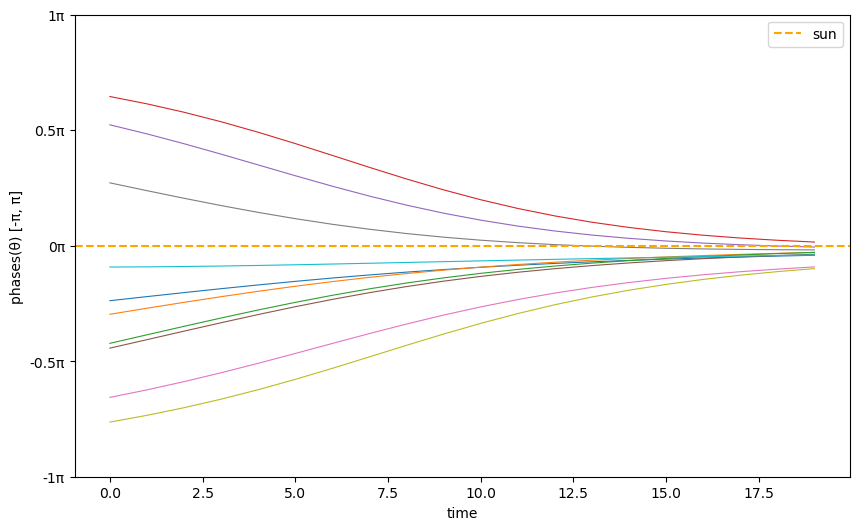

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot theta_history (assuming it's already defined)
for i in range(theta_history.shape[1]):  # loop over columns
    ax.plot(time, theta_history[:, i], lw=0.8)

# Horizontal line at y = 0
ax.axhline(
    y=0,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label='sun'
)

# Set y-axis limits to -pi to pi
ax.set_ylim(-np.pi, np.pi)

# Set tick spacing (π/2)
ax.yaxis.set_major_locator(MultipleLocator(np.pi/2))

# Format ticks as multiples of π
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: f"{val/np.pi:.1g}π")
)

# Labels and legend
ax.set_xlabel('time')
ax.set_ylabel('phases(θ) [-π, π]')
ax.legend()

# Show plot
plt.show()